# **IBM Telco Customer Churn Dataset — Exploratory Data Analysis (EDA)**

### **Objective:**
Identify the key drivers of customer churn in a telecom dataset to surface actionable retention opportunities.

**This EDA focuses on:**

- How contract type, tenure, and payment behaviour drive churn risk
- How demographic groups (senior citizens, dependents, partner status) differ in churn rates
- Where service configuration (internet type, tech support, service count) creates retention risk
- What churned customers themselves say about why they left

###**Dataset:**
7,032 customers | 24 features | 26.58% overall churn rate

## **File Upload**

In [ ]:
# file upload cell for Colab environment only.
from google.colab import files
uploaded = files.upload()

Saving telco_churn_cleaned.csv to telco_churn_cleaned.csv


## **Importing Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## **Loading Data**

In [ ]:
df = pd.read_csv('/content/telco_churn_cleaned.csv')

## **Dataset Overview**

In [ ]:
df.shape

(7032, 24)

In [ ]:
df.dtypes

,0
Gender,object
Senior Citizen,object
Partner,object
Dependents,object
Tenure Months,int64
Tenure Groups,object
Phone Service,object
Multiple Lines,object
Internet Service,object
Online Security,object


In [ ]:
df.isnull().sum()

,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Tenure Groups,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0


The only nulls are in churn reason column and that is expected because the customers who did not churn is not going to have a reason for churning hehe. Everything is good!

## **EDA**

### **Overall Churn distribution**
**Question:** What is the baseline churn rate?

In [ ]:
#setting a consistent theme
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
retained_color = '#4C9BE8'
churned_color = '#E05C5C'

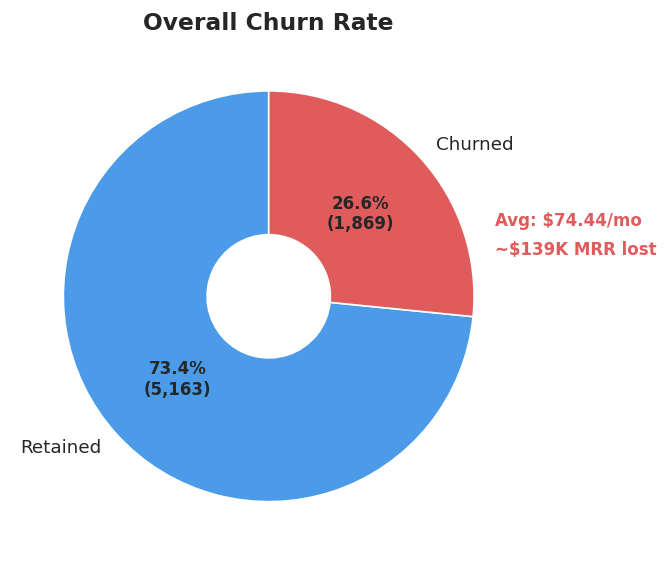

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

churn_counts = df['Churn Value'].value_counts()
labels = ['Retained', 'Churned']
sizes  = [churn_counts[0], churn_counts[1]]
colors = [retained_color, churned_color]

mean_churned_charge = df[df['Churn Value'] == 1]['Monthly Charges'].mean()
mrr_lost = mean_churned_charge * sizes[1]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100 * sum(sizes))):,})',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.7)
)

for at in autotexts:
    at.set(fontsize=10, fontweight='bold')

# Stacked annotation outside churned wedge
ax.annotate(
    f'Avg: ${mean_churned_charge:.2f}/mo\n~${mrr_lost/1000:.0f}K MRR lost',
    xy=(1.1, 0.3),
    fontsize=10,
    fontweight='bold',
    color=churned_color,
    ha='left',
    va='center',
    linespacing=1.8
)

ax.set_title('Overall Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

**Finding:** Roughly **1 in 4 customers churned** — a 26.6% churn rate (1,869 out of 7,032 customers).

**Business Implication:** At an average monthly charge of \$74.44 per churned customer, that's **~\$139K** in MRR walking out the door every month. This isn't a minor leakage problem — it's a central business risk. The rest of this analysis is about understanding *who* churns and *why*, so that the right customers can be targeted before they leave.

###**Churn Rate by Contract Type**
**Question:** Does the type of contract a customer holds predict whether they churn?

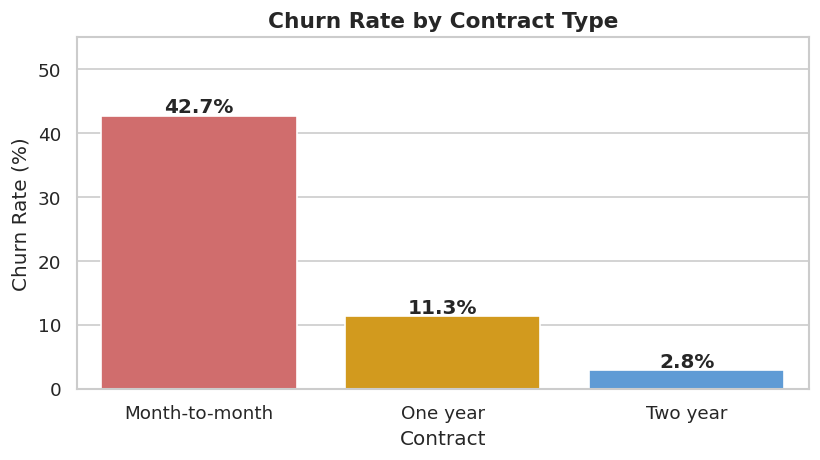

In [ ]:
contract_churn = (
    df.groupby('Contract')['Churn Value']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'Churn Value': 'Churn Rate (%)'})
    .sort_values('Churn Rate (%)', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = sns.barplot(
    data=contract_churn,
    x='Contract', y='Churn Rate (%)',
    palette=['#e05c5c', '#f0a500', '#4c9be8'],
    ax=ax
)

for bar, val in zip(bars.patches, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

**Finding:**
Month-to-month customers churn at **42.7%** — nearly 15x the rate of customers
on two-year contracts (**2.8%**). Each step up in contract length cuts churn dramatically.

**Business Implication:** Contract type is the single strongest predictor of churn in this dataset. Converting even a fraction of the monthly contracts to annual contracts would have a larger impact on churn than almost any other single intervention. Retention offers, loyalty discounts or contract upgrade incentives should prioritise this segment first.

### **Churn Rate by Tenure Group**
**Question:** At what point in the customer lifecycle is churn risk highest?

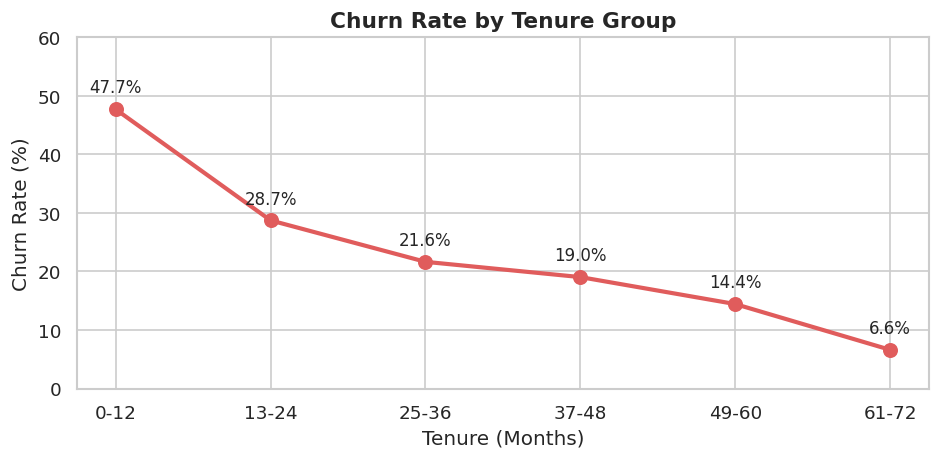

In [ ]:
tenure_churn = (
    df.groupby('Tenure Groups')['Churn Value']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'Churn Value': 'Churn Rate (%)'})
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tenure_churn['Tenure Groups'], tenure_churn['Churn Rate (%)'],
        marker='o', color='#e05c5c', linewidth=2.5, markersize=8)

for i, row in tenure_churn.iterrows():
    ax.annotate(f"{row['Churn Rate (%)']:.1f}%",
                xy=(row['Tenure Groups'], row['Churn Rate (%)']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10)

ax.set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

**Finding:** Churn is highest in the **first 12 months (47.7%)** and drops steadily to just **6.6%** by year six.

**Business Implication:** Churn is overwhelmingly an early-lifecycle problem. A customer who survives past 24 months is unlikely to leave. This points to a clear intervention window: onboarding experience, early engagement and first-year retention programmes will have disproportionate impact.

### **Churn Rate by Internet Service Type**
**Question:** Does the type of internet service a customer uses affect their likelihood of churning?

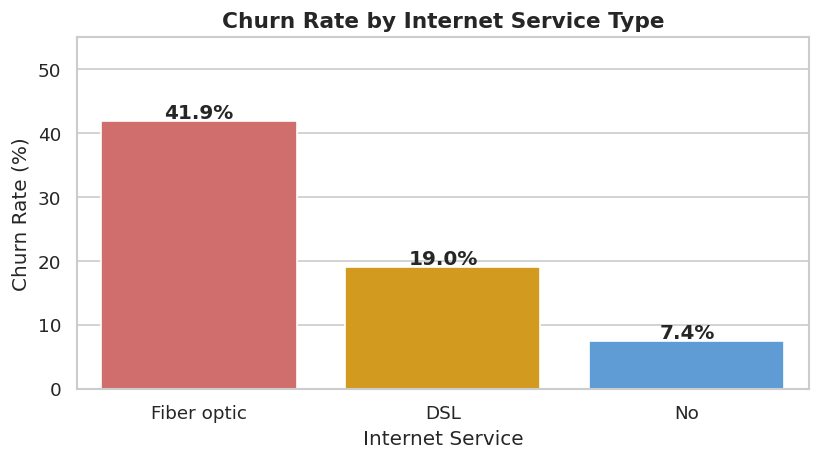

In [ ]:
contract_churn = (
    df.groupby('Internet Service')['Churn Value']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'Churn Value': 'Churn Rate (%)'})
    .sort_values('Churn Rate (%)', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = sns.barplot(
    data=contract_churn,
    x='Internet Service', y='Churn Rate (%)',
    palette=['#e05c5c', '#f0a500', '#4c9be8'],
    ax=ax
)

for bar, val in zip(bars.patches, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

**Finding:** Fiber optic customers churn at **41.9%** — more than double the DSL rate (**19%**) and nearly six times the rate of customers with no internet (**7.4%**). This is counterintuitive: fiber is the premium product, yet it has the worst retention.

**Business Implication:** This signals a service quality or value perception problem specific to fiber, not a general churn issue. Fiber customers are likely paying more and expecting more. The gap between expectations and delivery — whether in reliability, support, or competitive pricing — is driving them out. Fiber churn needs to be investigated separately from the overall churn problem.

### **Risk Concentration: Contract × Internet Service**
**Question:** Where is churn risk most concentrated when contract type and internet service are combined?

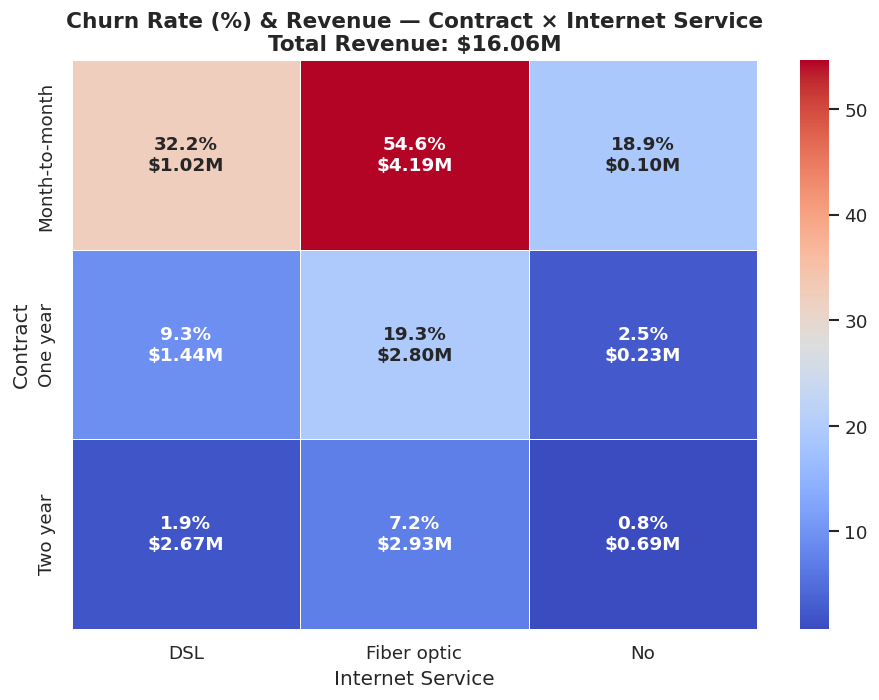

In [ ]:
pivot_churn = df.pivot_table(
    index='Contract',
    columns='Internet Service',
    values='Churn Value',
    aggfunc='mean'
).mul(100).reindex(['Month-to-month', 'One year', 'Two year'])

pivot_revenue = df.pivot_table(
    index='Contract',
    columns='Internet Service',
    values='Total Charges',
    aggfunc='sum'
).div(1000000).reindex(['Month-to-month', 'One year', 'Two year'])

total_revenue = pivot_revenue.values.sum()

# Build annotation: "Churn%\n$xM"
annot = pd.DataFrame(
    [
        [f"{pivot_churn.iloc[r, c]:.1f}%\n${pivot_revenue.iloc[r, c]:.2f}M"
         for c in range(pivot_churn.shape[1])]
        for r in range(pivot_churn.shape[0])
    ],
    index=pivot_churn.index,
    columns=pivot_churn.columns
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_churn, annot=annot, fmt='', cmap='coolwarm',
    linewidths=0.5, ax=ax,
    annot_kws={'fontsize': 11, 'fontweight': 'bold'}
)

ax.set_title(
    f'Churn Rate (%) & Revenue — Contract × Internet Service\nTotal Revenue: ${total_revenue:.2f}M',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

**Finding:**
The heatmap reveals that churn risk is heavily concentrated in **Month-to-month** contracts, particularly among **Fiber optic customers (54.6%)**, while Two-year contracts remain stable across all service types **(0.8%–7.2%)**. Notably, the **Fiber optic + Month-to-month** cell generates the highest revenue at **\$4.19M** yet carries the worst churn rate — making it the most volatile segment in the portfolio. **Two-year contracts** collectively hold **\$6.29M** in revenue at minimal churn, representing the **most stable customer base.**

**Business Implication:**
Immediate retention efforts should target Fiber optic + Month-to-month customers, as converting even a fraction of them to longer contracts would yield the highest revenue protection given that the churn drop from Month-to-month to One-year contracts is dramatic across all service types (e.g., **54.6% → 19.3%** for Fiber optic). Simultaneously, proactive renewal incentives should be in place for Two-year contract holders before expiry, as this segment represents the most valuable and stable revenue base and losing them would be costly to recover.

### **Internet Service × Tech Support: Churn Risk Matrix**
**Question:** Among internet users, does having a tech support plan meaningfully reduce churn among DSL and Fiber Optic users?

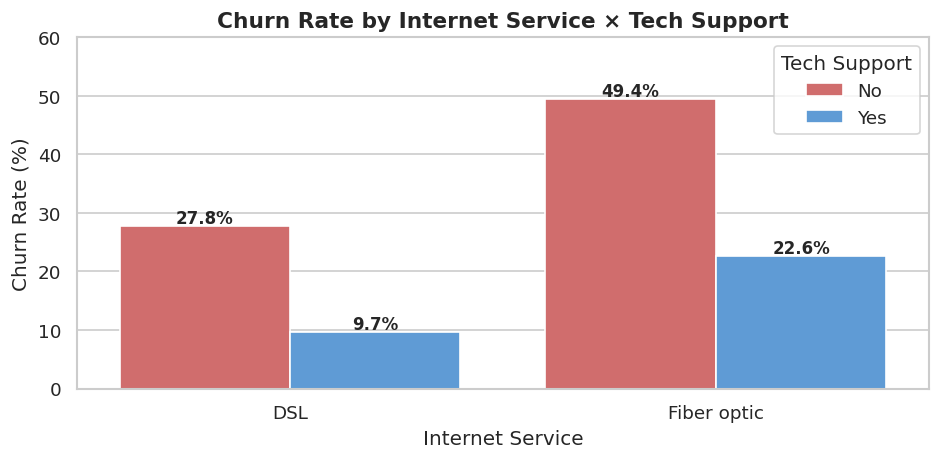

In [ ]:
fiber_dsl = df[
    (df['Internet Service'].isin(['Fiber optic', 'DSL'])) &
    (df['Tech Support'].isin(['Yes', 'No']))
].copy()

ts_churn = (
    fiber_dsl.groupby(['Internet Service', 'Tech Support'])['Churn Value']
    .mean().mul(100).reset_index()
    .rename(columns={'Churn Value': 'Churn Rate (%)'})
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=ts_churn,
    x='Internet Service', y='Churn Rate (%)',
    hue='Tech Support',
    palette={'Yes': '#4c9be8', 'No': '#e05c5c'},
    ax=ax
)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Churn Rate by Internet Service × Tech Support',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 60)
ax.legend(title='Tech Support')
plt.tight_layout()
plt.show()

**Finding:** Tech support halves churn across both service types. For fiber optic customers without tech support, churn hits **49.4%** — nearly one in two. Adding tech support brings that down to **22.6%**. DSL shows the same pattern: **27.8% without vs 9.7%** with.

**Business Implication:** Fiber optic customers without tech support are the single highest-risk segment in the dataset. Given that fiber optic already shows elevated churn(**41.9%**), the combination of no tech support + fiber is a critical flag. Proactively offering or bundling tech support for fiber customers — particularly new ones in the 0–12 month window — directly addresses the highest-risk cohort.

### **Monthly Charges and Total Charges Distribution by Churn Status**
**Question:** Do churned customers tend to pay more or less per month and in total?

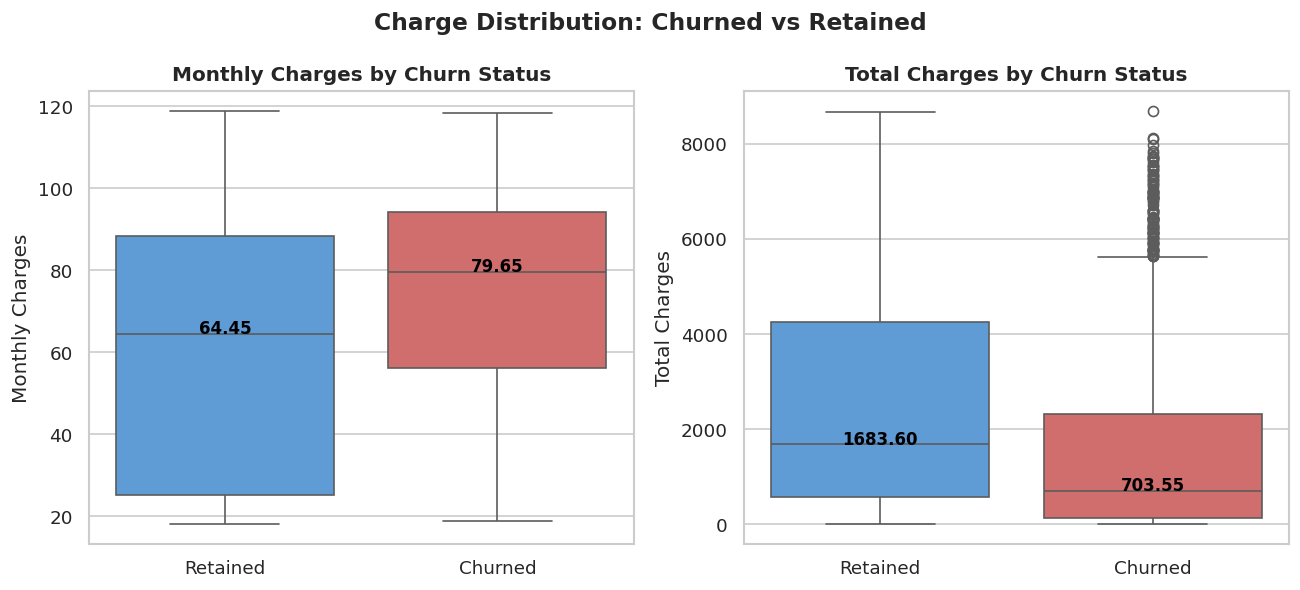

In [ ]:
df['Churn Label'] = df['Churn Value'].map({0: 'Retained', 1: 'Churned'})

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

medians = df.groupby('Churn Label')[['Monthly Charges', 'Total Charges']].median()

for i, (ax, col, title) in enumerate(
    zip(
        axes,
        ['Monthly Charges', 'Total Charges'],
        ['Monthly Charges by Churn Status', 'Total Charges by Churn Status']
    )
):
    sns.boxplot(
        data=df, x='Churn Label', y=col,
        hue = 'Churn Label',
        palette={'Retained': retained_color, 'Churned': churned_color},
        ax=ax,
        order=['Retained', 'Churned'] # Ensure correct order on x-axis
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

    # Annotate median values
    for j, churn_label in enumerate(['Retained', 'Churned']):
        median_val = medians.loc[churn_label, col]
        ax.text(j, median_val, f'{median_val:.2f}',
                horizontalalignment='center', color='black', weight='bold', fontsize=10)


plt.suptitle('Charge Distribution: Churned vs Retained', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

**Finding:** Churned customers actually paid **more per month** on average (**\$79.65 vs \$64.45** for retained), but far less in total (averaging **\$703.55 vs \$1683.60**). This isn't a contradiction. Churned customers left too early to accumulate total charges, not because they were paying less.

**Business Implication:** Higher-paying customers are more likely to leave. This is the opposite of what we want. This finding directly motivates targeted retention investment for high-charge customers, since the revenue impact of losing them is largest.

### **Churn Rate by Demographics (Senior Citizen,Partners & Dependents)**
**Question:** Do household demographics predict churn risk?

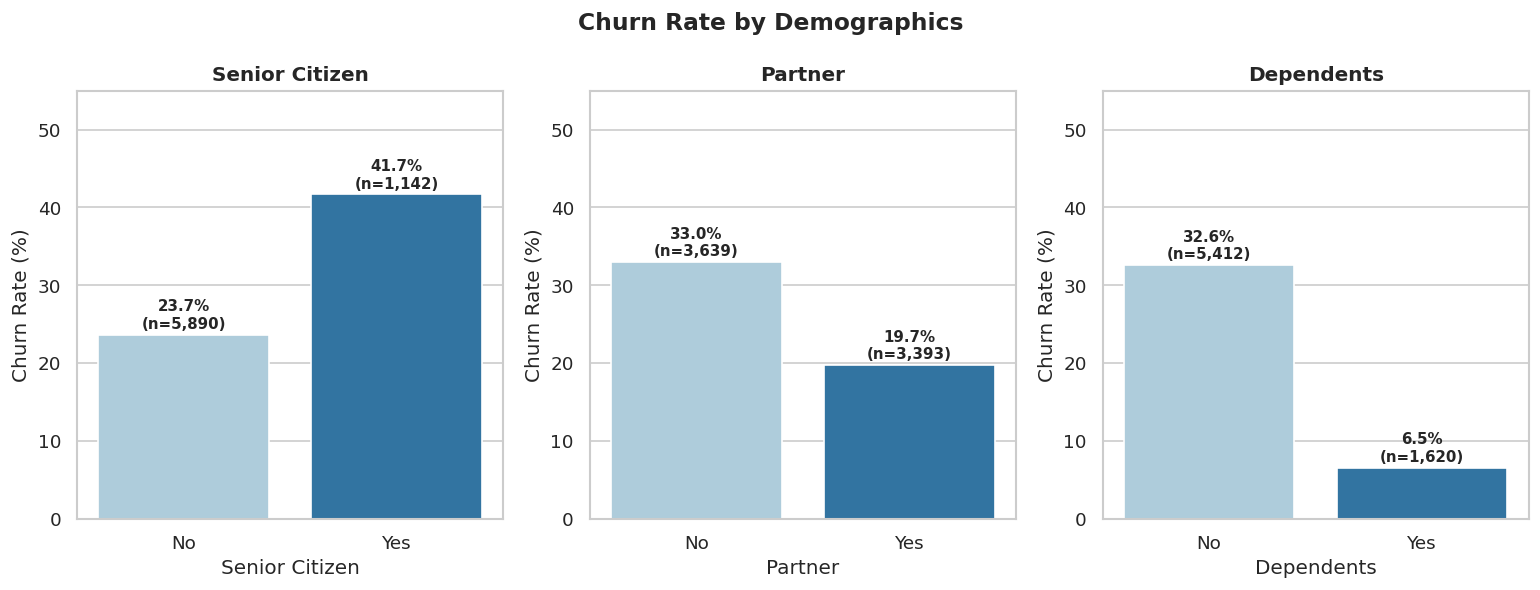

In [ ]:
demo_configs = [
    ('Senior Citizen', ['No', 'Yes']),
    ('Partner',        ['No', 'Yes']),
    ('Dependents',     ['No', 'Yes']),
]

for col, order in demo_configs:
    demo_churn = (
        df.groupby(col)['Churn Value']
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={'Churn Value': 'Churn Rate (%)'})
        .loc[lambda x: x[col].isin(order)]
        .set_index(col)
        .loc[order]
        .reset_index()
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Churn Rate by Demographics', fontsize=14, fontweight='bold')

for ax, (col, order) in zip(axes, demo_configs):
    demo_churn = (
        df.groupby(col)['Churn Value']
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={'Churn Value': 'Churn Rate (%)'})
        .set_index(col)
        .loc[order]
        .reset_index()
    )

    bars = sns.barplot(
        data=demo_churn,
        x=col, y='Churn Rate (%)',
        palette='Paired',
        ax=ax,
        order=order
    )

    counts = df.groupby(col).size().loc[order]
    for bar, (_, row) in zip(bars.patches, demo_churn.iterrows()):
        n = counts[row[col]]
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{row['Churn Rate (%)']:.1f}%\n(n={n:,})",
                ha='center', fontsize=9, fontweight='bold')

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 55)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Finding:** We can see that senior citizens have the highest churn rate(**41.7%**). Now let us figure out the churn rate for the combined household demographics.

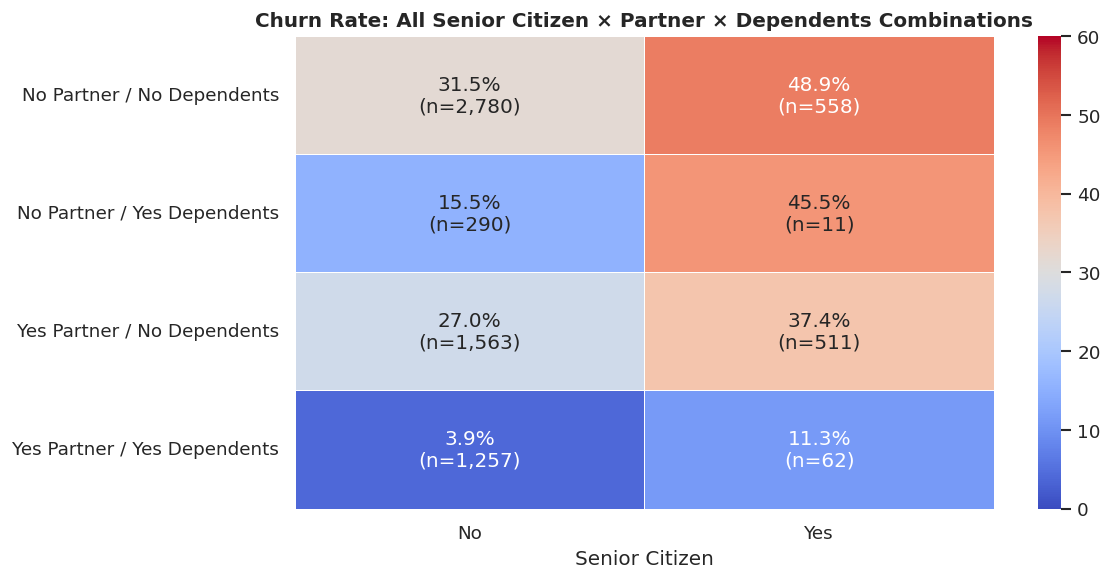

In [ ]:
combo_churn = (
    df.groupby(['Senior Citizen', 'Partner', 'Dependents'])['Churn Value']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Churn Rate (%)', 'count': 'n'})
)
combo_churn['Churn Rate (%)'] = combo_churn['Churn Rate (%)'].mul(100).round(1)
combo_churn['label'] = combo_churn.apply(
    lambda r: f"{r['Churn Rate (%)']:.1f}%\n(n={r['n']:,})", axis=1
)

combo_churn['Partner × Dependents'] = combo_churn['Partner'] + ' Partner / ' + combo_churn['Dependents'] + ' Dependents'

heatmap_data = combo_churn.pivot(index='Partner × Dependents', columns='Senior Citizen', values='Churn Rate (%)')
heatmap_labels = combo_churn.pivot(index='Partner × Dependents', columns='Senior Citizen', values='label')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=heatmap_labels,
    fmt='',
    cmap='coolwarm',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=60
)
ax.set_title('Churn Rate: All Senior Citizen × Partner × Dependents Combinations',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Senior Citizen')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Finding:** Household stability is the strongest demographic buffer against churn. Customers with both a partner and dependents churn at just **3.9%** — but that protection collapses for senior citizens in the same situation, who still churn at **11.3%**. At the other extreme, seniors with no partner and no dependents churn at **48.9%**, making them the most isolated and highest-risk demographic segment in the dataset.

**Business Implication:** The priority segment here is seniors without household anchors. They have no structural reason to stay and are unlikely to respond to digital retention nudges. Proactive outreach (phone-based, not app-based) with a contract conversion offer targeted specifically at this group would address the highest-risk demographic cohort.

### **Senior Citizens on Month-to-Month Contracts: The Highest-Risk Segment**
**Question:** How does contract type interact with senior citizen status to define the riskiest customer profiles?

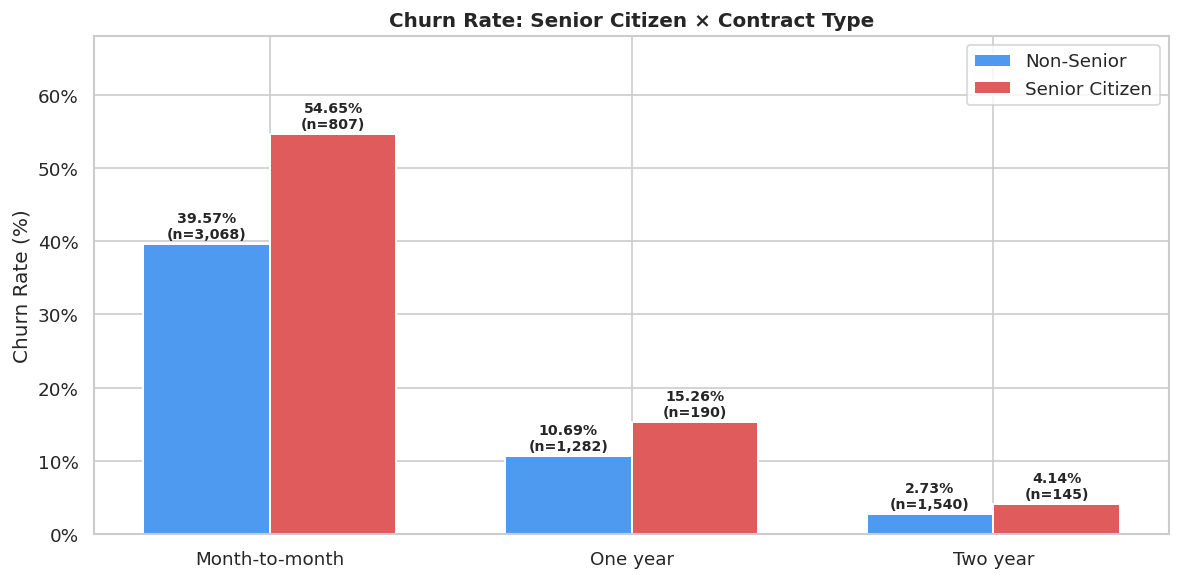

In [ ]:
sc_contract = (df.groupby(['Senior Citizen', 'Contract'])['Churn Value']
                  .agg(['sum','count'])
                  .rename(columns={'sum':'churned','count':'total'}))
sc_contract['churn_rate'] = (sc_contract['churned'] / sc_contract['total'] * 100).round(2)
sc_contract = sc_contract.reset_index()

contract_order = ['Month-to-month', 'One year', 'Two year']
sc_contract['Contract'] = pd.Categorical(sc_contract['Contract'],
                                          categories=contract_order, ordered=True)
sc_contract = sc_contract.sort_values(['Senior Citizen', 'Contract'])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(contract_order))
width = 0.35

non_senior = sc_contract[sc_contract['Senior Citizen'] == 'No']
senior     = sc_contract[sc_contract['Senior Citizen'] == 'Yes']

bars1 = ax.bar(x - width/2, non_senior['churn_rate'].values, width,
               label='Non-Senior', color='#4e9af1', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, senior['churn_rate'].values, width,
               label='Senior Citizen', color='#e05c5c', edgecolor='white', linewidth=1.2)

for bars, data in [(bars1, non_senior), (bars2, senior)]:
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f"{row['churn_rate']}%\n(n={row['total']:,})",
                ha='center', fontsize=8.5, fontweight='bold')

ax.set_title('Churn Rate: Senior Citizen × Contract Type', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contract_order)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 68)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend()

plt.tight_layout()
plt.show()

**Finding:** Senior citizens on month-to-month contracts churn at **54.65%** — the highest rate of any segment in this analysis. Even for two-year contracts, seniors churn at **4.14% vs 2.73%** for non-seniors, showing elevated risk across the board.

**Business Implication:** This segment requires a dedicated retention strategy, not just general churn interventions. Senior customers on month-to-month contracts are likely more price-sensitive and less likely to engage with digital self-service, which means retention outreach needs to be proactive and channel-appropriate (phone, not push notification). A senior-specific contract conversion offer could meaningfully reduce churn in this high-risk cohort.

### **Churn Rate by Payment Method**
**Question:** Is the way a customer pays linked to whether they churn?

In [ ]:
print(df['Payment Method'].unique())

['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:
# grouping the automatic methods together
df['Payment Method'] = df['Payment Method'].replace({
    'Bank transfer (automatic)': 'Automatic',
    'Credit card (automatic)': 'Automatic'
})

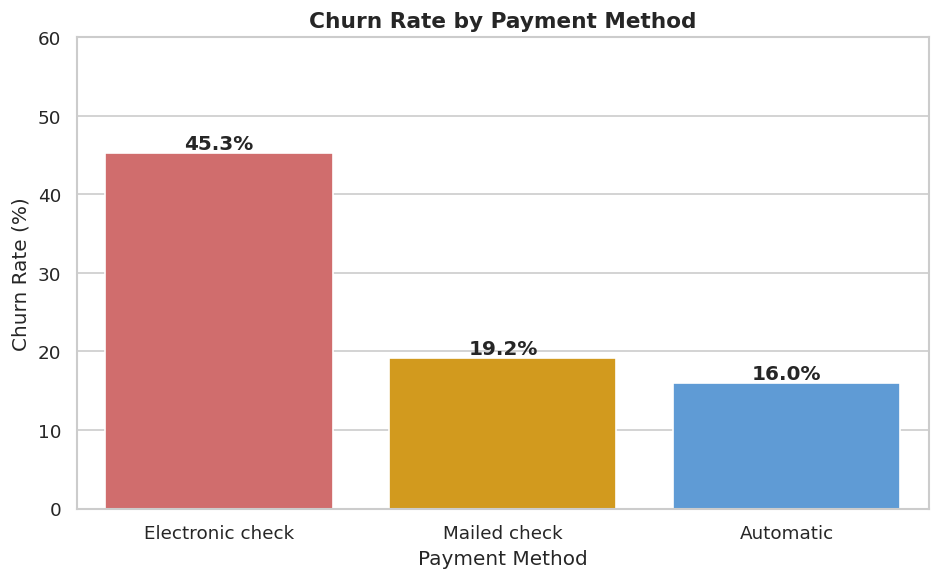

In [ ]:
payment_churn = (
    df.groupby('Payment Method')['Churn Value']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'Churn Value': 'Churn Rate (%)'})
    .sort_values('Churn Rate (%)', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=payment_churn,
    x='Payment Method', y='Churn Rate (%)',
    palette=['#e05c5c', '#f0a500', '#4c9be8'],
    ax=ax
)

for bar, val in zip(ax.patches, payment_churn['Churn Rate (%)']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%', ha='center', fontweight='bold'
    )

ax.set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

**Finding:** Electronic check customers churn at **45.3%** — nearly 3x the rate of automatic payment methods (**16%**). Mailed check sits in the middle at **19.2%**.

**Business Implication:** Automatic payment methods create passive retention because customers aren't actively making a monthly decision to stay. Electronic check customers, by contrast, manually engage with their bill every month, which creates a regular decision point to reconsider. Nudging electronic check users to switch to auto-pay is a low-friction, high-value retention action.

### **Churn Rate by Number of Services Subscribed**
**Question:** Does subscribing to more services reduce churn?

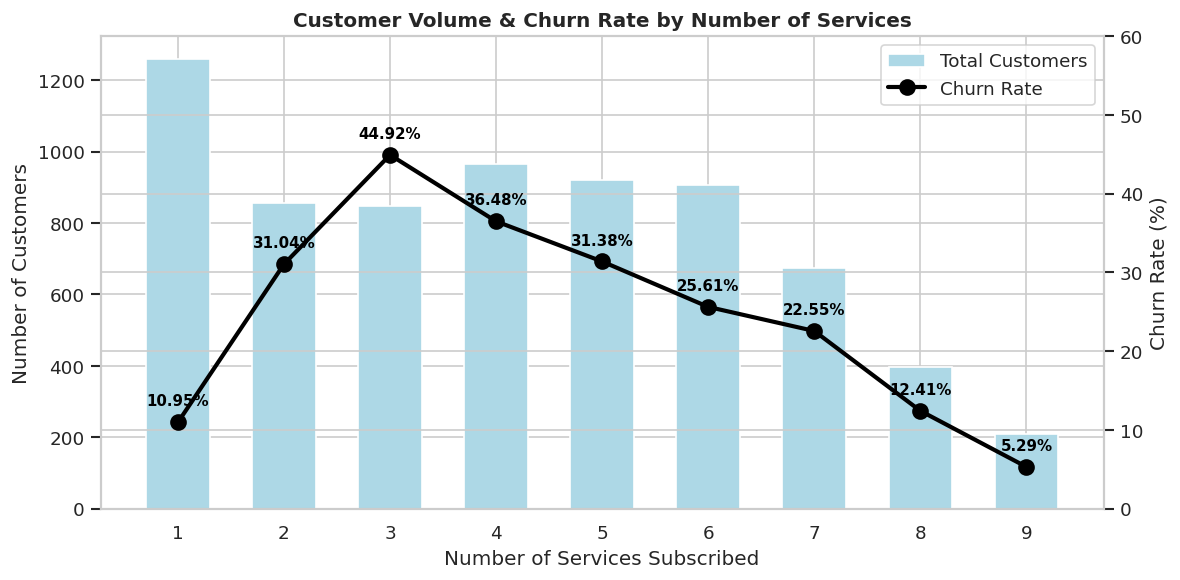

In [ ]:
svc_stats = (df.groupby('Service Count')['Churn Value']
               .agg(['sum','count'])
               .rename(columns={'sum':'churned','count':'total'}))
svc_stats['churn_rate'] = (svc_stats['churned'] / svc_stats['total'] * 100).round(2)
svc_stats = svc_stats.sort_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(svc_stats.index, svc_stats['total'], color='#ADD8E6',
        width=0.6, label='Total Customers')
ax2.plot(svc_stats.index, svc_stats['churn_rate'], color='#000000',
         marker='o', linewidth=2.5, markersize=9, label='Churn Rate')

for x, (rate, total) in zip(svc_stats.index, zip(svc_stats['churn_rate'], svc_stats['total'])):
    ax2.annotate(f'{rate}%', (x, rate),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, fontweight='bold', color='#000000')

ax1.set_title('Customer Volume & Churn Rate by Number of Services', fontweight='bold')
ax1.set_xlabel('Number of Services Subscribed')
ax1.set_ylabel('Number of Customers')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, 60)
ax1.set_xticks(svc_stats.index)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

**Finding:** The relationship is non-linear. Churn peaks at **3 services (44.9%)** then steadily declines to just **5.3% at 9 services**. But critically, customers with only **1 service** also churn relatively little (**10.95%**), possibly because the price is low. Let us confirm this possibility with the plot below.

**Business Implication:** The 3–5 service range is the danger zone. These customers have enough services to be paying a meaningful amount but not enough product depth to feel locked in. Customers at 6+ services become dramatically more retained. Product bundles that push the 3–5 service group toward 6+ (e.g., a bundled discount at the 6-service tier) could directly address this pattern.

### **Charge Category x Number of Services: Churn Risk**
**Question:** Is the churn relatively lower for customers with 1 services because the price is low?

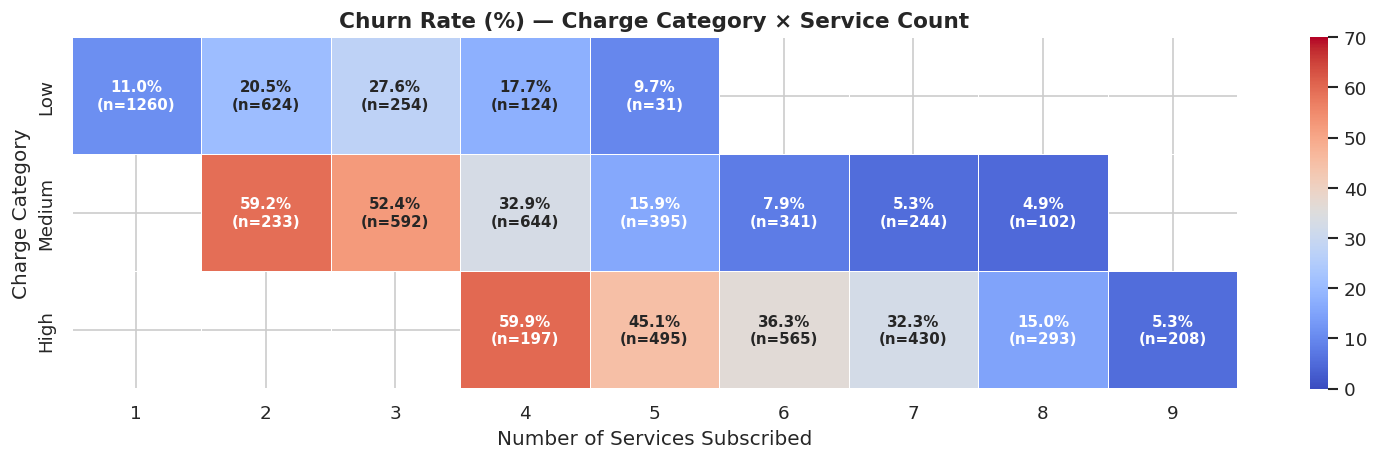

In [ ]:
pivot_churn = df.pivot_table(
    index='Charge Category',
    columns='Service Count',
    values='Churn Value',
    aggfunc='mean'
).mul(100).reindex(['Low', 'Medium', 'High'])

pivot_counts = df.pivot_table(
    index='Charge Category',
    columns='Service Count',
    values='Churn Value',
    aggfunc='count'
).reindex(['Low', 'Medium', 'High'])

annot = pd.DataFrame(
    [
        [
            f"{pivot_churn.iloc[r, c]:.1f}%\n(n={int(pivot_counts.iloc[r, c])})"
            if not pd.isna(pivot_churn.iloc[r, c]) else "—"
            for c in range(pivot_churn.shape[1])
        ]
        for r in range(pivot_churn.shape[0])
    ],
    index=pivot_churn.index,
    columns=pivot_churn.columns
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot_churn,
    annot=annot,
    fmt='',
    cmap='coolwarm',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=70,
    annot_kws={'fontsize': 9, 'fontweight': 'bold'}
)

ax.set_title(
    'Churn Rate (%) — Charge Category × Service Count',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Number of Services Subscribed')
ax.set_ylabel('Charge Category')
plt.tight_layout()
plt.show()

**Finding:** It can be seen that for lower service count, the charge is very low with lower churn rate **(11%)**, which confirms that cheaper charge accounts for lower churn risk for the customers subscribed to one service.

### **Why Do Customers Actually Leave?**
**Question:** Among customers who gave a reason for leaving, what categories of reasons dominate?

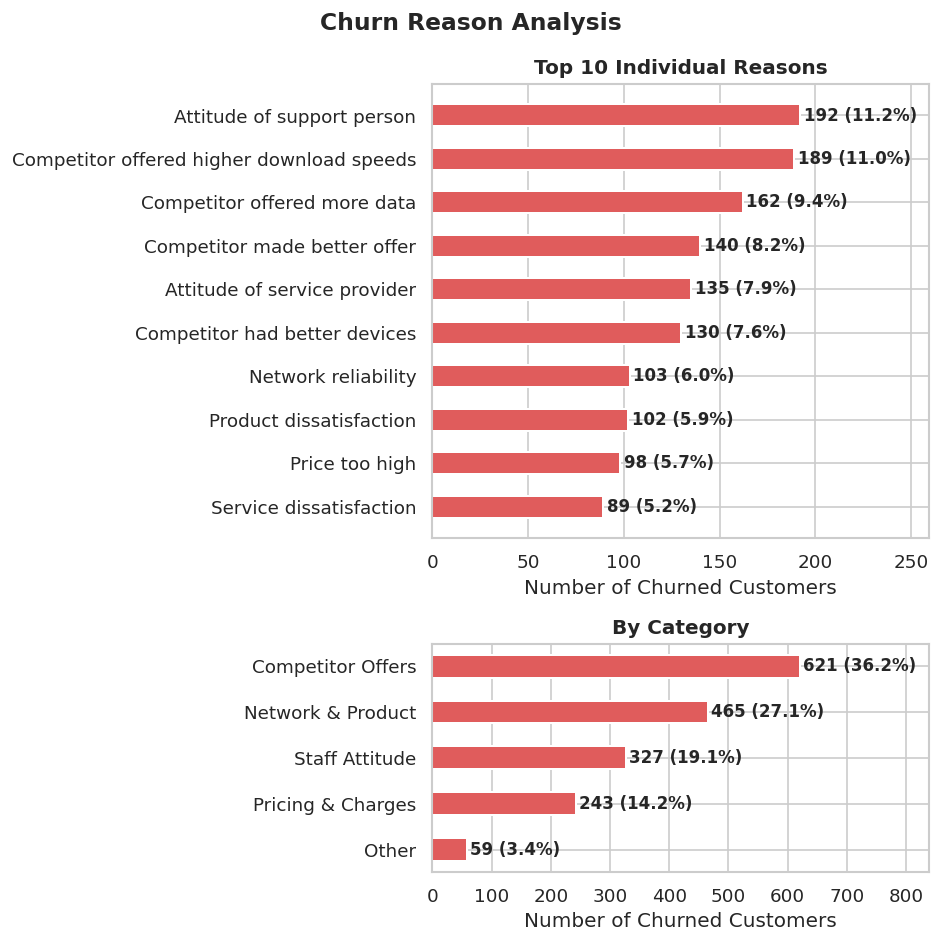

In [ ]:
churned_with_reason = df[
    (df['Churn Value'] == 1) &
    (df['Churn Reason'].notna()) &
    (df['Churn Reason'] != '') &
    (df['Churn Reason'] != "Don't know")
].copy()

category_map = {
    'Competitor offered higher download speeds': 'Competitor Offers',
    'Competitor offered more data':              'Competitor Offers',
    'Competitor made better offer':              'Competitor Offers',
    'Competitor had better devices':             'Competitor Offers',
    'Attitude of support person':                'Staff Attitude',
    'Attitude of service provider':              'Staff Attitude',
    'Network reliability':                       'Network & Product',
    'Product dissatisfaction':                   'Network & Product',
    'Service dissatisfaction':                   'Network & Product',
    'Lack of self-service on Website':           'Network & Product',
    'Limited range of services':                 'Network & Product',
    'Poor expertise of phone support':           'Network & Product',
    'Poor expertise of online support':          'Network & Product',
    'Price too high':                            'Pricing & Charges',
    'Extra data charges':                        'Pricing & Charges',
    'Lack of affordable download/upload speed':  'Pricing & Charges',
    'Long distance charges':                     'Pricing & Charges',
    'Moved':                                     'Other',
    'Deceased':                                  'Other',
}

churned_with_reason['Category'] = churned_with_reason['Churn Reason'].map(category_map).fillna('Other')

fig = plt.figure(figsize=(8, 8)) # Adjust figure size for better display
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1]) # Make the top subplot twice as tall as the bottom
fig.suptitle('Churn Reason Analysis', fontsize=14, fontweight='bold')

category_counts = churned_with_reason['Category'].value_counts().sort_values(ascending=True)
top10_individual = churned_with_reason['Churn Reason'].value_counts().head(10).sort_values(ascending=True)

total_with_reason = len(churned_with_reason)

# Top subplot: top 10 individual reasons
ax0 = fig.add_subplot(gs[0, 0])
bars = ax0.barh(top10_individual.index, top10_individual.values,
                    color=churned_color, edgecolor='white',
                    linewidth=1.2, height=0.5)
for bar, val in zip(bars, top10_individual.values):
    pct = val / total_with_reason * 100
    ax0.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax0.set_title('Top 10 Individual Reasons', fontweight='bold') # Changed to Top 10
ax0.set_xlabel('Number of Churned Customers')
ax0.xaxis.grid(True); ax0.set_axisbelow(True)
ax0.set_xlim(0, max(top10_individual.values) * 1.35)

# Bottom subplot: category bar
ax1 = fig.add_subplot(gs[1, 0])
bars2 = ax1.barh(category_counts.index, category_counts.values,
                     color=churned_color,
                     edgecolor='white', linewidth=1.2, height=0.5)
for bar, val in zip(bars2, category_counts.values):
    pct = val / total_with_reason * 100
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax1.set_title('By Category', fontweight='bold')
ax1.set_xlabel('Number of Churned Customers')
ax1.xaxis.grid(True); ax1.set_axisbelow(True)
ax1.set_xlim(0, max(category_counts.values) * 1.35)

plt.tight_layout()
plt.show()

**Findings:**
- Among customers who gave a reason, **competitor-related reasons** account for **36.2%** of known churn — by far the largest category.
- Staff attitude account for **19.1%** — the single largest individual driver is attitude of the support person at **11.2%**.
- Price being too high ranks only 9th at **5.7%**, suggesting price alone is not the core retention problem.

**Business Implication:** The primary churn problem is competitive, not operational. Customers are being pulled away by better offers, faster speeds, and more data — not primarily pushed away by bad service. This is important for strategy: fixing internal processes will have limited impact if competitors continue to offer superior products at similar prices. The company needs a competitive response on product (speed, data) rather than just a service quality improvement programme. Staff attitude, however, ranks first in individual churn reason. Thus frontline staff interactions are also a significant independent factor worth addressing.

---
## **Key Findings Summary**

1. **26.58% overall churn rate** — roughly 1 in 4 customers lost, translating to a \$139K reduction in MRR.

2. **Contract type is the strongest predictor of churn.** Month-to-month customers churn at 42.7% — nearly 15x the two-year rate (2.85%).

3. **Churn is an early-lifecycle problem.** 47.7% of customers in their first year churn. Past month 24, it drops to below 22% and keeps falling.

4. **Fiber optic has a product-level churn problem.** At 41.9%, fiber customers churn at more than double the DSL rate (19%) despite paying a premium. This points to unmet expectations, not just general dissatisfaction.

5. **Fiber optic + no tech support = 49.4% churn** — the highest-risk product configuration. Tech support roughly halves churn for both fiber and DSL customers.

6. **The hottest segment in the dataset is also the most volatile.** Fiber optic + month-to-month customers churn at 54.6% yet generate the highest revenue at $4.19M.

7. **Electronic check customers churn at 45.3%** — nearly 3x the auto-pay rate (16%). Auto-pay functions as passive retention; electronic check creates a monthly re-evaluation moment.

8. **Senior citizens on month-to-month contracts churn at 54.65%** — the highest of any segment. Seniors without a partner or dependents push close to 49% even in isolation.

9. **Service depth drives loyalty.** Churn peaks at 3 services (44.9%) then falls to 5.3% at 9 services. The 3–5 service range is the most vulnerable mid-tier.

10. **Competitors are the #1 stated reason for leaving (36.2%), but staff attitude is the largest single individual driver (11.2%).** These are two separate, actionable problems — one external (product competitiveness), one internal (frontline behaviour). Price ranks 9th at 5.7% — the problem is product competitiveness, not pricing.

---
## **Business Recommendations**

**1. Make contract conversion the primary retention lever with a dedicated senior retention track.**

The 15x churn gap makes this the highest-ROI single action available. A targeted discount or loyalty incentive for contract upgrades — specifically within the first 12 months — simultaneously addresses the contract type and the tenure risk window in one move. For senior citizens specifically — who churn at 54.65% on month-to-month — the outreach channel matters: phone-based contact and simplified contract options with senior specific discounts, not app notifications or digital nudges.

**2. Fix the first year or lose the customer permanently.**

Almost half of year-one customers churn. Structured check-ins, proactive support and early engagement incentives between months 1–6 address the period of maximum risk before it becomes a loss.

**3. Address staff attitude as a standalone priority.**

Staff attitude is the single largest individual churn reason at 11.2%. This is an internal problem fully within the company's control. Frontline training, quality monitoring and accountability mechanisms should be treated as a direct retention investment, not just a service improvement exercise.

**4. Bundle tech support into fiber onboarding and run an auto-pay nudge campaign on electronic check users.**

Fiber customers without tech support are a near-50% churn risk — including tech support in a fiber welcome bundle could halve churn in that cohort. Separately, nudging electronic check users to switch to auto-pay is low-cost and directly cuts a clear behavioural churn driver.

**5. Build a competitive response on product.**

Competitors are pulling customers away with better speeds, more data and stronger offers. Thus fixing internal processes alone won't stop that. A product/pricing review against key competitors is necessary.
